# Cloud Fraction Correlation

This notebook matches Planet cloud fraction separately with Landsat, Sentinel-2, Terra MODIS, and Aqua MODIS observations, then plots correlation scatterplots.

Terra and Aqua are separate satellite platforms carrying MODIS instruments with different overpass times. They are therefore retained as separate comparisons rather than averaged into a combined Aqua/Terra daily cloud fraction. Matching by calendar date still does not guarantee simultaneous observations, so interpret same-day correlations with that timing limitation in mind.

Edit the **Config** cell first. The notebook expects CSV files with columns like `time`, `cloud_fraction_1km`, and `satellite`. It also accepts common alternatives such as `date`, `datetime`, `cloud_fraction`, `cloud_cover`, `sensor`, or `platform`.

## Config

In [15]:
import os
from pathlib import Path

# BASE_PATH points to your OneDrive folder so the notebook can move across machines.
# If your OneDrive environment variable is missing, set BASE_PATH manually below.
BASE_PATH = Path(os.environ.get("OneDrive", ""))
if not BASE_PATH:
    raise EnvironmentError("OneDrive environment variable not found. Set BASE_PATH manually in this cell.")

# Same OneDrive data structure used by config.py.
DATA_ROOT = BASE_PATH / "classmaterials" / "BLab_research_data" / "Beth_research_data"

# Local project folder. This is where Planet output and notebook results live.
# If you clone/move this repo, change only this PROJECT_ROOT line.
PROJECT_ROOT = Path.cwd()

GAUGE_ID = "gauge3"
EXPORT_GAUGE_ID = GAUGE_ID.replace("_", "")  # external CSV names use gauge1, gauge2, ...
PLANET_RUN = f"{GAUGE_ID}_planet_lookup_2026_06_15"

# Planet cloud-fraction output from this project.
PLANET_CSV = PROJECT_ROOT / "output" / "metadata" / PLANET_RUN / f"{EXPORT_GAUGE_ID}_cloud_fraction.csv"
# "F:\Research_PhD\Beth_research\output\metadata\gauge1_planet_lookup_2026_06_15\gauge1_cloud_fraction.csv"

# Other satellite cloud-fraction CSVs stored under OneDrive.
# Edit these filenames/folders to match your GEE exports.
# Set a path to None if you do not want to run that comparison yet.
AQUA_TERRA_DIR = DATA_ROOT / "aquaandterra_clouds"
SENSOR_FILES = {
    "terra": [
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MOD_part1.csv",  # Terra MODIS
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MOD_part2.csv",
    ],
    "aqua": [
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MYD_part1.csv",  # Aqua MODIS
        AQUA_TERRA_DIR / f"{EXPORT_GAUGE_ID}_MYD_part2.csv",
    ],
    "sentinel_2": DATA_ROOT / "Sentinel2_CloudCover_1km" / f"Sentinel2_CloudCover_1km_{EXPORT_GAUGE_ID}.csv",
    "landsat": DATA_ROOT / "Landsat_CloudFraction_1km" / f"Landsat_CloudFraction_1km_{EXPORT_GAUGE_ID}.csv",
}

# If Landsat/Sentinel-2/Aqua/Terra are all in one CSV, point each sensor above
# to that same file and use satellite_filters below to separate them.
SATELLITE_FILTERS = {
    "landsat": "landsat",
    "sentinel_2": "sentinel",  # use "sentinel-2" if that is exactly in your CSV
    "terra": "terra",
    "aqua": "aqua",
}

# Date range for the comparison. Use None to keep the full available period.
START_DATE = "2016-01-01"
END_DATE = "2026-03-08"

# 0 = exact same calendar date only.
# Use 1 or 2 if sparse satellite revisit dates need nearest Planet observations.
MATCH_WINDOW_DAYS = 0

# How to combine multiple images from the same platform on the same day:
# "mean", "median", "min", or "max". Aqua and Terra are never combined.
DAILY_STAT = "mean"

# Keep revised platform-specific results separate from legacy pooled Aqua/Terra outputs.
OUT_DIR = PROJECT_ROOT / "output" / "correlation" / PLANET_RUN 
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Imports And Helper Functions

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TIME_CANDIDATES = ("datetime", "acquired", "acquisition_time", "system:time_start", "date", "time", "system:index")
CLOUD_CANDIDATES = ("cloud_fraction_1km", "cloud_fraction", "cloud_cover", "cloud", "clouds", "mean_cloud_1km")
SATELLITE_CANDIDATES = ("satellite", "sensor", "satellite_name", "platform", "id")


def find_column(df, candidates, required=True):
    lower_to_original = {col.lower().strip(): col for col in df.columns}
    for candidate in candidates:
        key = candidate.lower().strip()
        if key in lower_to_original:
            return lower_to_original[key]
    if required:
        raise ValueError(f"Could not find one of {candidates}. Columns found: {list(df.columns)}")
    return None


def parse_system_index(series):
    text = series.astype(str).str.extract(r"(\d{8}T\d{6})", expand=False)
    return pd.to_datetime(text, format="%Y%m%dT%H%M%S", errors="coerce")


def parse_time_column(series):
    numeric_time = pd.to_numeric(series, errors="coerce")
    if numeric_time.notna().any():
        max_value = numeric_time.dropna().abs().max()
        if max_value > 1e11:
            return pd.to_datetime(numeric_time, unit="ms", errors="coerce")
        if max_value > 1e8:
            return pd.to_datetime(numeric_time, unit="s", errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def parse_observation_time(df):
    lower_to_original = {col.lower().strip(): col for col in df.columns}

    # Some GEE exports have separate date and time columns.
    # Example Sentinel-2 rows: date=2025-01-02, time=16:13:34.
    if "date" in lower_to_original and "time" in lower_to_original:
        date_col = lower_to_original["date"]
        time_col = lower_to_original["time"]
        combined = df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip()
        parsed = pd.to_datetime(combined, errors="coerce")
        if parsed.notna().any():
            return parsed

    # Sentinel-2 system:index can look like 20250102T160559_20250102T161016_T17SPU.
    if "system:index" in lower_to_original:
        parsed = parse_system_index(df[lower_to_original["system:index"]])
        if parsed.notna().any():
            return parsed

    time_col = find_column(df, TIME_CANDIDATES)
    return parse_time_column(df[time_col])


def read_one_cloud_csv(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"File does not exist: {csv_path}")
    df = pd.read_csv(csv_path)
    df["source_file"] = csv_path.name
    return df


def load_cloud_csv(csv_path, label, satellite_filter=None, start_date=None, end_date=None, daily_stat="mean"):
    if isinstance(csv_path, (list, tuple, set)):
        frames = [read_one_cloud_csv(path) for path in csv_path]
        df = pd.concat(frames, ignore_index=True)
    else:
        df = read_one_cloud_csv(csv_path)

    cloud_col = find_column(df, CLOUD_CANDIDATES)
    satellite_col = find_column(df, SATELLITE_CANDIDATES, required=False)

    clean = pd.DataFrame({
        "time": parse_observation_time(df),
        "cloud_fraction": pd.to_numeric(df[cloud_col], errors="coerce"),
    })

    # GEE exports often store cloud cover as a percentage from 0 to 100.
    # Planet output is already a fraction from 0 to 1.
    if clean["cloud_fraction"].dropna().gt(1).any():
        clean["cloud_fraction"] = clean["cloud_fraction"] / 100.0

    if satellite_col:
        clean["satellite"] = df[satellite_col].astype(str).str.lower().str.strip()
    else:
        clean["satellite"] = label.lower()

    # For Aqua/Terra files, infer the platform from MOD/MYD filenames when no
    # satellite column exists. MOD = Terra, MYD = Aqua.
    source_lower = df["source_file"].astype(str).str.lower()
    clean.loc[source_lower.str.contains("_mod_", na=False), "satellite"] = "terra"
    clean.loc[source_lower.str.contains("_myd_", na=False), "satellite"] = "aqua"

    clean = clean.dropna(subset=["time", "cloud_fraction"])
    clean = clean[(clean["cloud_fraction"] >= 0) & (clean["cloud_fraction"] <= 1)]

    if satellite_filter:
        clean = clean[clean["satellite"].str.contains(satellite_filter, case=False, na=False, regex=True)]

    if start_date:
        clean = clean[clean["time"].dt.date >= pd.to_datetime(start_date).date()]
    if end_date:
        clean = clean[clean["time"].dt.date <= pd.to_datetime(end_date).date()]

    clean["date"] = clean["time"].dt.floor("D")
    daily = (
        clean.groupby("date", as_index=False)
        .agg(cloud_fraction=("cloud_fraction", daily_stat), n_observations=("cloud_fraction", "size"))
        .sort_values("date")
    )
    daily = daily.rename(columns={
        "cloud_fraction": f"{label}_cloud_fraction",
        "n_observations": f"{label}_n",
    })
    return daily


def match_cloud_fraction(planet_daily, other_daily, tolerance_days=0):
    if tolerance_days == 0:
        matched = planet_daily.merge(other_daily, on="date", how="inner")
        matched["planet_date"] = matched["date"]
        matched["other_date"] = matched["date"]
        matched["date_difference_days"] = 0
        return matched

    planet_for_match = planet_daily.rename(columns={"date": "planet_date"})
    other_for_match = other_daily.rename(columns={"date": "other_date"})
    matched = pd.merge_asof(
        other_for_match.sort_values("other_date"),
        planet_for_match.sort_values("planet_date"),
        left_on="other_date",
        right_on="planet_date",
        direction="nearest",
        tolerance=pd.Timedelta(days=tolerance_days),
    ).dropna(subset=["planet_cloud_fraction"])
    matched["date_difference_days"] = (matched["other_date"] - matched["planet_date"]).dt.days
    return matched


def summarize_stats(matched, other_label):
    x = matched["planet_cloud_fraction"]
    y = matched[f"{other_label}_cloud_fraction"]
    diff = y - x
    return {
        "sensor": other_label,
        "n": int(len(matched)),
        "pearson_r": x.corr(y, method="pearson"),
        "spearman_r": x.corr(y, method="spearman"),
        "bias_other_minus_planet": diff.mean(),
        "rmse": np.sqrt(np.mean(diff**2)),
    }


def plot_correlation(matched, other_label, stats, out_png=None):
    x = matched["planet_cloud_fraction"].to_numpy()
    y = matched[f"{other_label}_cloud_fraction"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
    ax.scatter(x, y, s=42, alpha=0.78, edgecolor="white", linewidth=0.6)
    ax.plot([0, 1], [0, 1], color="0.45", linestyle="--", linewidth=1.2, label="1:1")

    if len(matched) >= 2 and np.nanstd(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(0, 1, 100)
        ax.plot(xx, slope * xx + intercept, color="#bf3f3f", linewidth=1.6, label="fit")

    annotation = (
        f"n = {stats['n']}\n"
        f"Pearson r = {stats['pearson_r']:.3f}\n"
        f"Spearman r = {stats['spearman_r']:.3f}\n"
        f"Bias = {stats['bias_other_minus_planet']:.3f}\n"
        f"RMSE = {stats['rmse']:.3f}"
    )
    ax.text(0.04, 0.96, annotation, transform=ax.transAxes, ha="left", va="top", fontsize=10,
            bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.92})

    ax.set_title(f"Cloud Fraction Correlation: Planet vs {other_label.replace('_', ' ').title()}")
    ax.set_xlabel("Planet cloud fraction")
    ax.set_ylabel(f"{other_label.replace('_', ' ').title()} cloud fraction")
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.grid(True, color="0.9", linewidth=0.8)
    ax.legend(loc="lower right")
    fig.tight_layout()
    if out_png:
        fig.savefig(out_png)
    return fig, ax

## Load Planet Data

In [17]:
planet_raw = pd.read_csv(PLANET_CSV)
planet_times = parse_observation_time(planet_raw).dropna()

print(f"Planet CSV: {PLANET_CSV}")
print(f"Planet raw rows: {len(planet_raw)}")
if len(planet_times):
    print(f"Planet raw date range: {planet_times.min().date()} to {planet_times.max().date()}")
print(f"Notebook date filter: {START_DATE} to {END_DATE}")

planet_daily = load_cloud_csv(
    PLANET_CSV,
    label="planet",
    satellite_filter=None,
    start_date=START_DATE,
    end_date=END_DATE,
    daily_stat=DAILY_STAT,
)

print(f"Planet daily observations after filtering: {len(planet_daily)}")
if planet_daily.empty:
    print("No Planet rows remain after filtering. Check PLANET_RUN, START_DATE, and END_DATE in the Config cell.")

planet_daily.head()

Planet CSV: h:\Research_PhD\Beth_research\output\metadata\gauge3_planet_lookup_2026_06_15\gauge3_cloud_fraction.csv
Planet raw rows: 2601
Planet raw date range: 2016-08-24 to 2024-12-30
Notebook date filter: 2016-01-01 to 2026-03-08
Planet daily observations after filtering: 1481


,date,planet_cloud_fraction,planet_n
0,2016-08-24,0.000000,1
1,2016-08-25,0.694649,2
2,2016-09-24,0.719471,1
3,2016-09-30,0.018118,2
4,2016-10-14,0.760249,1


## Run All Sensor Correlations


Processing terra from 2 file(s):
  C:\Users\Yuyang\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge3_MOD_part1.csv
  C:\Users\Yuyang\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge3_MOD_part2.csv
terra daily observations after filtering: 2870


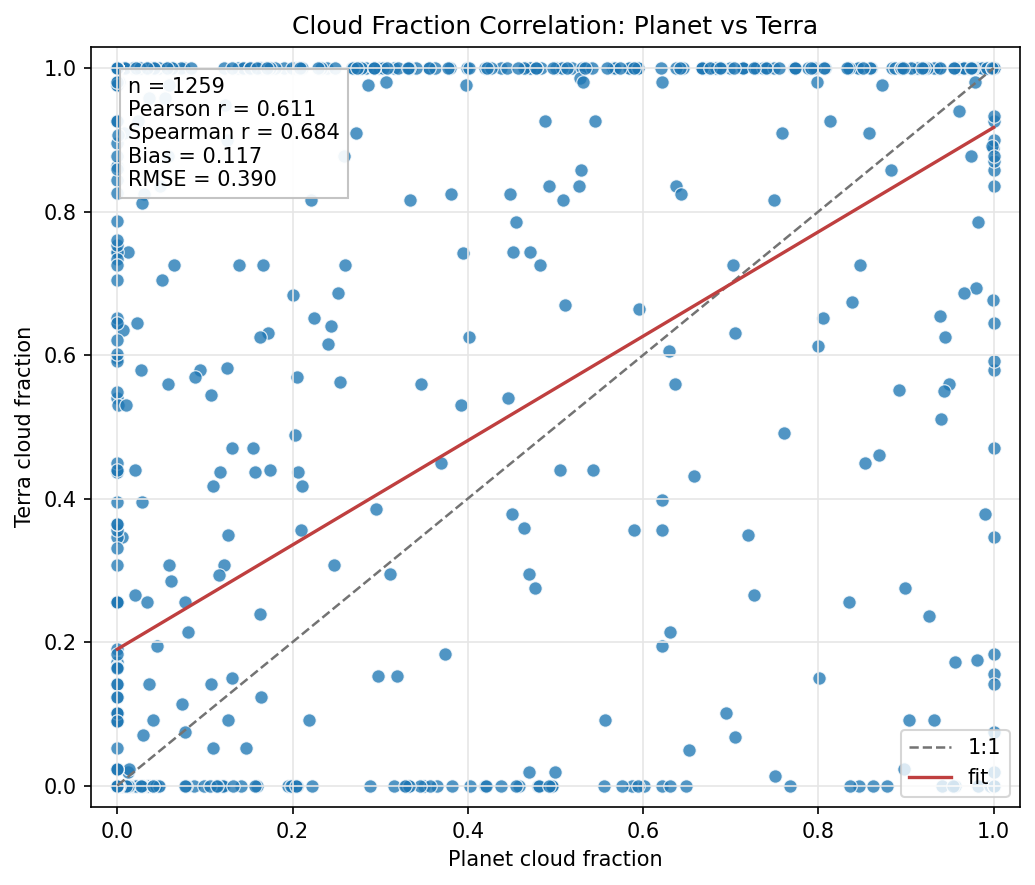

Matched observations: 1259
Pearson r: 0.611
Spearman r: 0.684
Bias (terra - Planet): 0.117
RMSE: 0.390
Saved matched CSV: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_terra_same_date_matched.csv
Saved figure: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_terra_same_date.png

Processing aqua from 2 file(s):
  C:\Users\Yuyang\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge3_MYD_part1.csv
  C:\Users\Yuyang\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\aquaandterra_clouds\gauge3_MYD_part2.csv
aqua daily observations after filtering: 2898


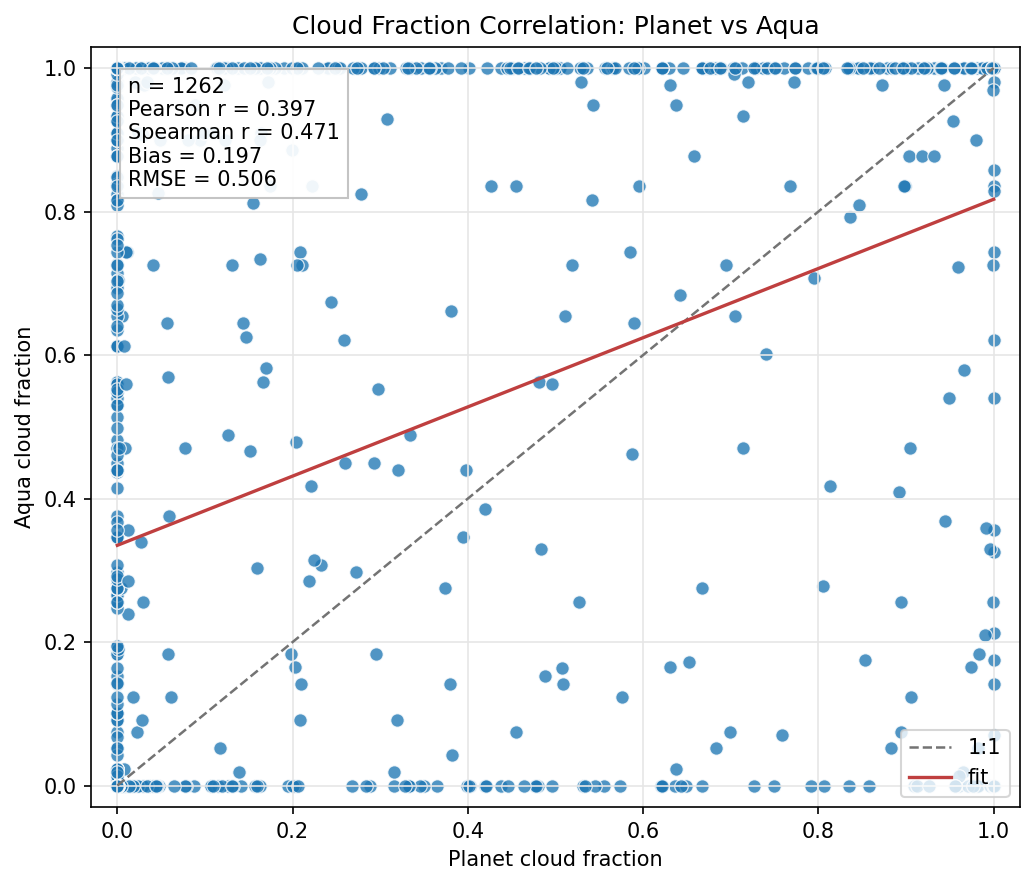

Matched observations: 1262
Pearson r: 0.397
Spearman r: 0.471
Bias (aqua - Planet): 0.197
RMSE: 0.506
Saved matched CSV: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_aqua_same_date_matched.csv
Saved figure: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_aqua_same_date.png

Processing sentinel_2 from 1 file(s):
  C:\Users\Yuyang\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\Sentinel2_CloudCover_1km\Sentinel2_CloudCover_1km_gauge3.csv
sentinel_2 daily observations after filtering: 965


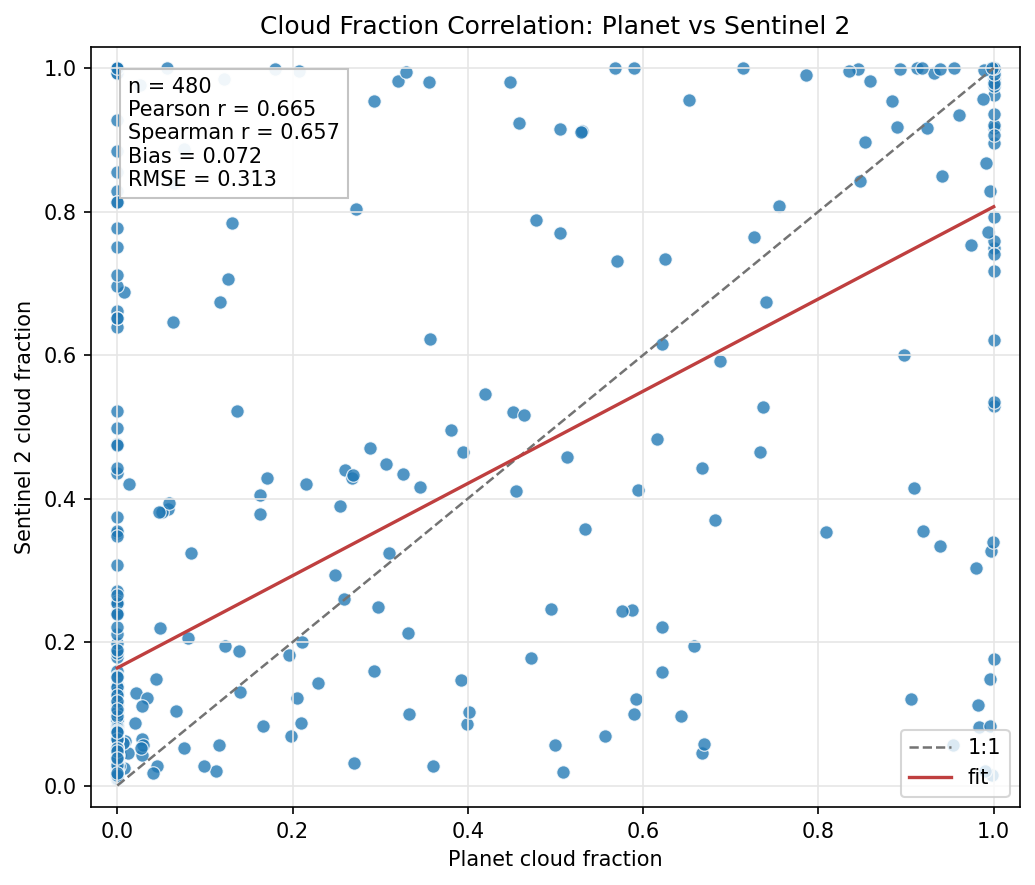

Matched observations: 480
Pearson r: 0.665
Spearman r: 0.657
Bias (sentinel_2 - Planet): 0.072
RMSE: 0.313
Saved matched CSV: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_sentinel_2_same_date_matched.csv
Saved figure: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_sentinel_2_same_date.png

Processing landsat from 1 file(s):
  C:\Users\Yuyang\OneDrive - Northeastern University\classmaterials\BLab_research_data\Beth_research_data\Landsat_CloudFraction_1km\Landsat_CloudFraction_1km_gauge3.csv
landsat daily observations after filtering: 272


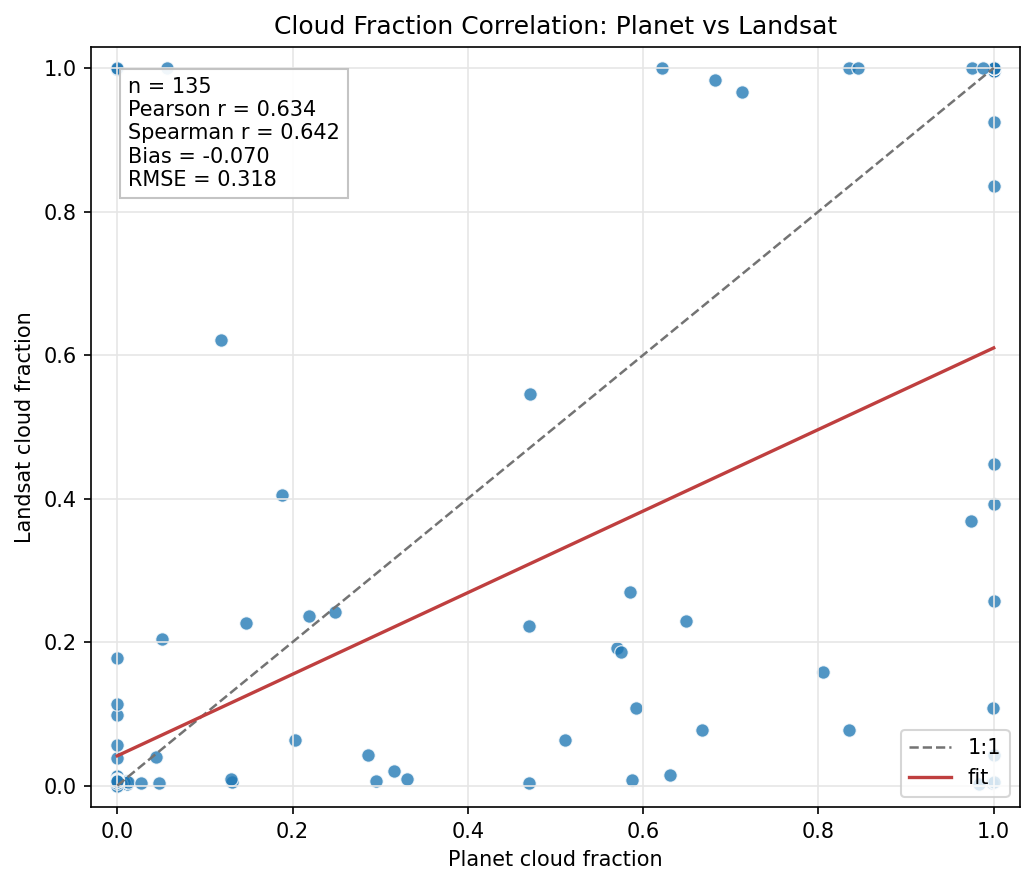

Matched observations: 135
Pearson r: 0.634
Spearman r: 0.642
Bias (landsat - Planet): -0.070
RMSE: 0.318
Saved matched CSV: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_landsat_same_date_matched.csv
Saved figure: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_vs_landsat_same_date.png


In [18]:
all_stats = []
matched_tables = {}

for sensor_label, sensor_csv in SENSOR_FILES.items():
    if sensor_csv is None:
        print(f"Skipping {sensor_label}: path is None")
        continue

    sensor_paths = list(sensor_csv) if isinstance(sensor_csv, (list, tuple, set)) else [sensor_csv]
    sensor_paths = [Path(path) for path in sensor_paths]
    missing_paths = [path for path in sensor_paths if not path.exists()]
    if missing_paths:
        print(f"Skipping {sensor_label}: missing file(s)")
        for path in missing_paths:
            print(f"  {path}")
        continue

    print(f"\nProcessing {sensor_label} from {len(sensor_paths)} file(s):")
    for path in sensor_paths:
        print(f"  {path}")
    other_daily = load_cloud_csv(
        sensor_paths,
        label=sensor_label,
        satellite_filter=SATELLITE_FILTERS.get(sensor_label),
        start_date=START_DATE,
        end_date=END_DATE,
        daily_stat=DAILY_STAT,
    )
    print(f"{sensor_label} daily observations after filtering: {len(other_daily)}")

    matched = match_cloud_fraction(planet_daily, other_daily, tolerance_days=MATCH_WINDOW_DAYS)
    if matched.empty:
        print(f"No matched observations for {sensor_label}. Try MATCH_WINDOW_DAYS = 1 or 2.")
        continue

    stats = summarize_stats(matched, sensor_label)
    all_stats.append(stats)
    matched_tables[sensor_label] = matched

    match_name = "same_date" if MATCH_WINDOW_DAYS == 0 else f"nearest_{MATCH_WINDOW_DAYS}d"
    matched_csv = OUT_DIR / f"planet_vs_{sensor_label}_{match_name}_matched.csv"
    out_png = OUT_DIR / f"planet_vs_{sensor_label}_{match_name}.png"
    matched.to_csv(matched_csv, index=False)
    plot_correlation(matched, sensor_label, stats, out_png=out_png)
    plt.show()

    print(f"Matched observations: {stats['n']}")
    print(f"Pearson r: {stats['pearson_r']:.3f}")
    print(f"Spearman r: {stats['spearman_r']:.3f}")
    print(f"Bias ({sensor_label} - Planet): {stats['bias_other_minus_planet']:.3f}")
    print(f"RMSE: {stats['rmse']:.3f}")
    print(f"Saved matched CSV: {matched_csv}")
    print(f"Saved figure: {out_png}")

## Summary Table

In [19]:
summary = pd.DataFrame(all_stats)
if summary.empty:
    print("No correlations were produced. Check file paths, satellite filters, and date range.")
else:
    summary_path = OUT_DIR / "planet_sensor_correlation_summary.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Saved summary: {summary_path}")
    display(summary)

Saved summary: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_sensor_correlation_summary.csv


,sensor,n,pearson_r,spearman_r,bias_other_minus_planet,rmse
0,terra,1259,0.611295,0.683515,0.116656,0.389851
1,aqua,1262,0.397109,0.470749,0.196844,0.505617
2,sentinel_2,480,0.665225,0.657430,0.071887,0.312540
3,landsat,135,0.634059,0.642164,-0.070136,0.317798


## Save All Matched Tables

In [20]:
if not matched_tables:
    print("No matched tables to combine.")
else:
    combined_matched = pd.concat(
        [table.assign(sensor=sensor) for sensor, table in matched_tables.items()],
        ignore_index=True,
        sort=False,
    )
    combined_path = OUT_DIR / "planet_all_sensors_matched.csv"
    combined_matched.to_csv(combined_path, index=False)
    print(f"Saved combined matched table: {combined_path}")
    print(f"Rows: {len(combined_matched)}")
    display(combined_matched.head(20))

Saved combined matched table: h:\Research_PhD\Beth_research\output\correlation\gauge3_planet_lookup_2026_06_15\planet_all_sensors_matched.csv
Rows: 3136


,date,planet_cloud_fraction,planet_n,terra_cloud_fraction,terra_n,planet_date,other_date,date_difference_days,sensor,aqua_cloud_fraction,aqua_n,sentinel_2_cloud_fraction,sentinel_2_n,landsat_cloud_fraction,landsat_n
0,2016-08-24,0.000000,1,0.000,1.0,2016-08-24,2016-08-24,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-08-25,0.694649,2,0.101,1.0,2016-08-25,2016-08-25,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-09-24,0.719471,1,0.349,1.0,2016-09-24,2016-09-24,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-09-30,0.018118,2,1.000,1.0,2016-09-30,2016-09-30,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-10-14,0.760249,1,0.491,1.0,2016-10-14,2016-10-14,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
5,2016-10-19,0.000000,2,0.000,1.0,2016-10-19,2016-10-19,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
6,2016-10-21,0.000000,1,0.000,1.0,2016-10-21,2016-10-21,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
7,2016-10-22,0.000000,2,0.000,1.0,2016-10-22,2016-10-22,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
8,2016-10-24,0.000000,1,0.000,1.0,2016-10-24,2016-10-24,0,terra,NaN,NaN,NaN,NaN,NaN,NaN
9,2016-10-29,0.000000,1,0.000,1.0,2016-10-29,2016-10-29,0,terra,NaN,NaN,NaN,NaN,NaN,NaN


## Inspect A Matched Table

Change `sensor_to_view` to `landsat`, `sentinel_2`, `terra`, or `aqua`.

In [21]:
sensor_to_view = "landsat"

if sensor_to_view in matched_tables:
    display(matched_tables[sensor_to_view].head(20))
else:
    print(f"No matched table available for {sensor_to_view}.")

,date,planet_cloud_fraction,planet_n,landsat_cloud_fraction,landsat_n,planet_date,other_date,date_difference_days
0,2016-10-22,0.000000,2,0.006088,1,2016-10-22,2016-10-22,0
1,2017-05-02,0.000000,1,0.011562,2,2017-05-02,2017-05-02,0
2,2017-07-05,0.000000,1,0.000435,2,2017-07-05,2017-07-05,0
3,2017-07-21,0.000000,2,0.001884,2,2017-07-21,2017-07-21,0
4,2017-08-22,0.202477,1,0.063989,1,2017-08-22,2017-08-22,0
5,2017-09-07,0.000000,1,0.002609,2,2017-09-07,2017-09-07,0
6,2017-09-23,0.315800,1,0.019649,1,2017-09-23,2017-09-23,0
7,2017-10-25,0.000000,3,0.006088,1,2017-10-25,2017-10-25,0
8,2017-11-10,0.000000,1,0.006958,1,2017-11-10,2017-11-10,0
9,2017-11-26,0.000000,1,0.006668,1,2017-11-26,2017-11-26,0
